#### Not

##### Verileri temizlemeden önceki kullandığımız grafiklerin aynısını temizlikten sonraki veriler içinden uygulancak


In [1]:
%run model.ipynb

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17201 entries, 0 to 17200
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Net_Metrekare       17201 non-null  int64  
 1   Brüt_Metrekare      17201 non-null  float64
 2   Oda_Sayısı          17201 non-null  float64
 3   Bulunduğu_Kat       17201 non-null  object 
 4   Binanın_Yaşı        17201 non-null  object 
 5   Isıtma_Tipi         17201 non-null  object 
 6   Fiyat               17201 non-null  float64
 7   Şehir               17201 non-null  object 
 8   Binanın_Kat_Sayısı  17201 non-null  int64  
 9   Kullanım_Durumu     17201 non-null  object 
 10  Banyo_Sayısı        17201 non-null  float64
dtypes: float64(4), int64(2), object(5)
memory usage: 1.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17201 entries, 0 to 17200
Columns: 115 entries, Net_Metrekare to Kullanım_Durumu_Mülk Sahibi Oturuyor
dtypes: bool(110), float64(3), int64(2)


In [2]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

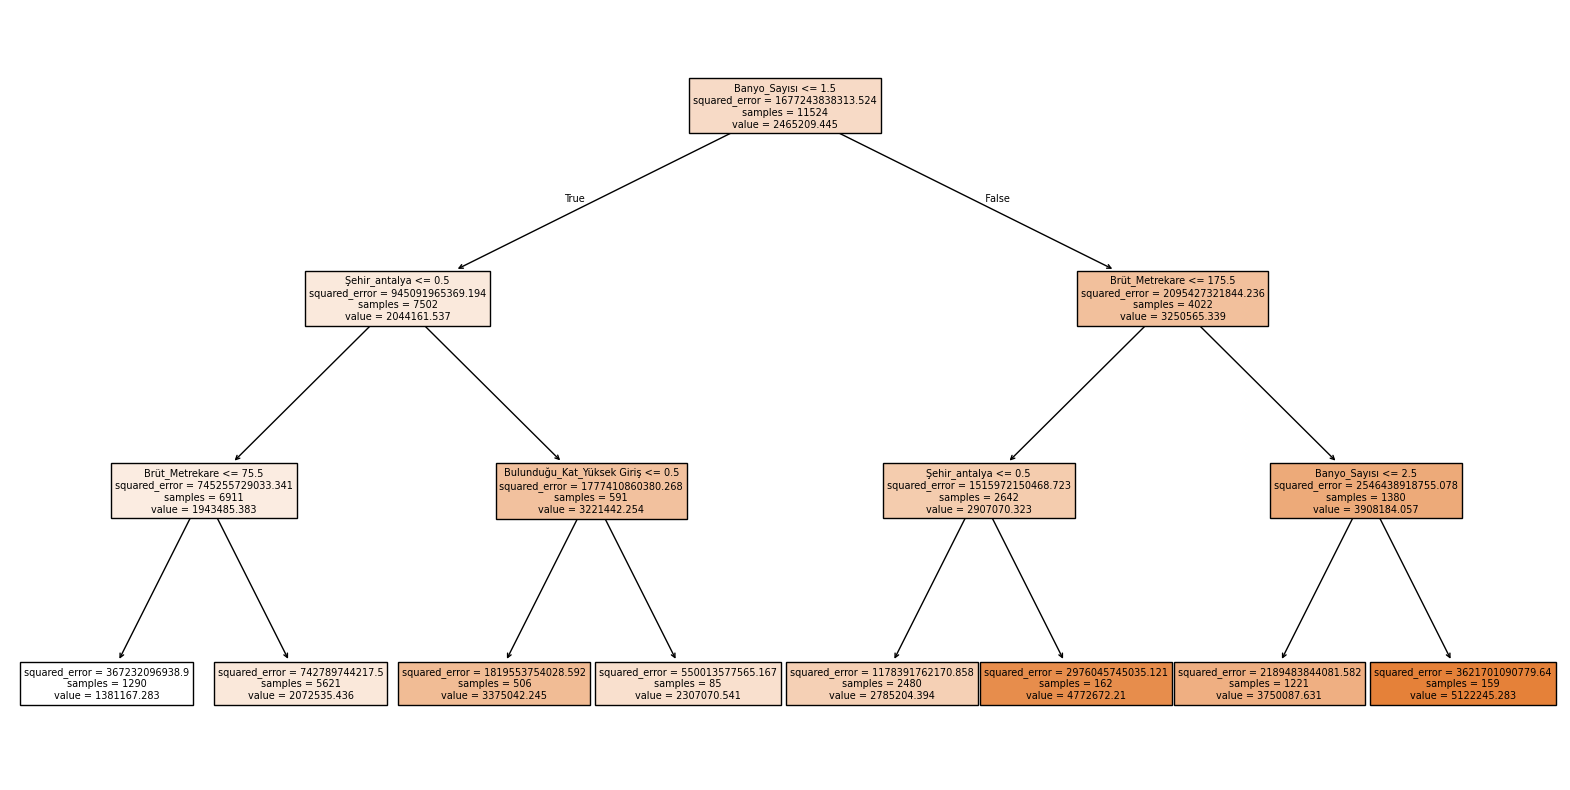

In [3]:

plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=x.columns,
    filled=True
)

plt.show()

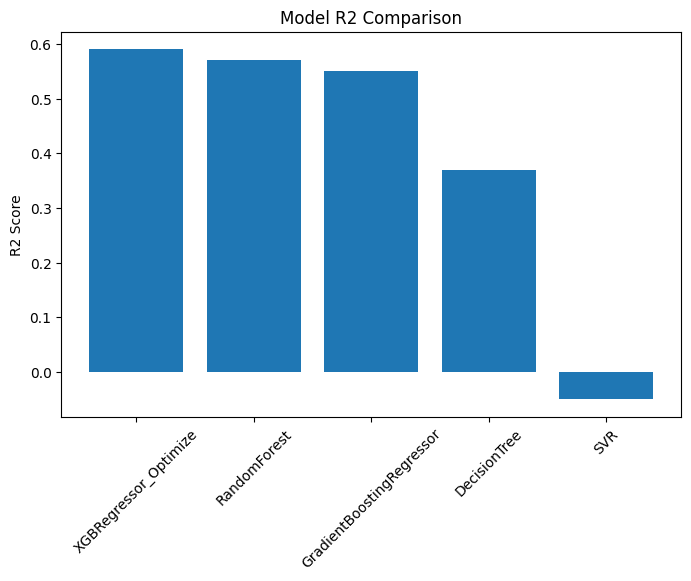

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["R2"])

plt.title("Model R2 Comparison")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)

plt.show()

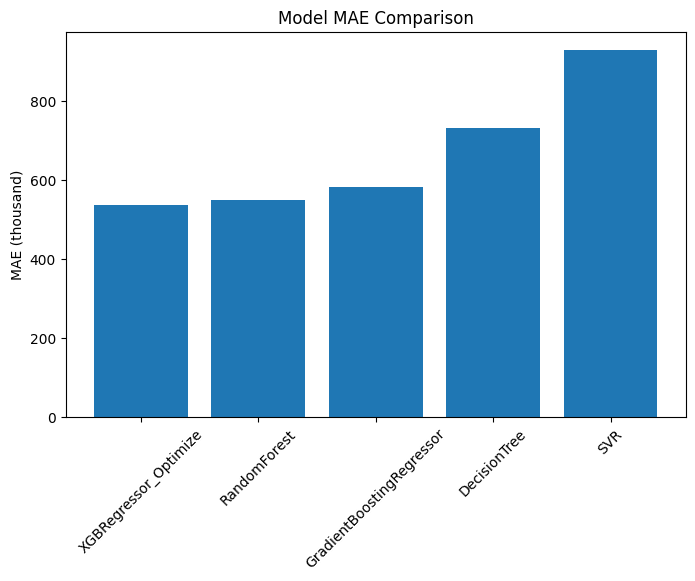

In [5]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["MAE"])

plt.title("Model MAE Comparison")
plt.ylabel("MAE (thousand)")
plt.xticks(rotation=45)

plt.show()

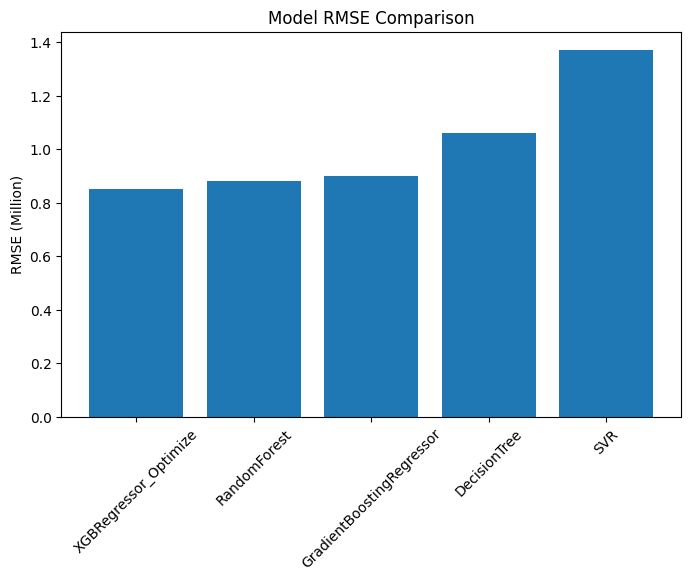

In [6]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("Model RMSE Comparison")
plt.ylabel("RMSE (Million)")
plt.xticks(rotation=45)

plt.show()

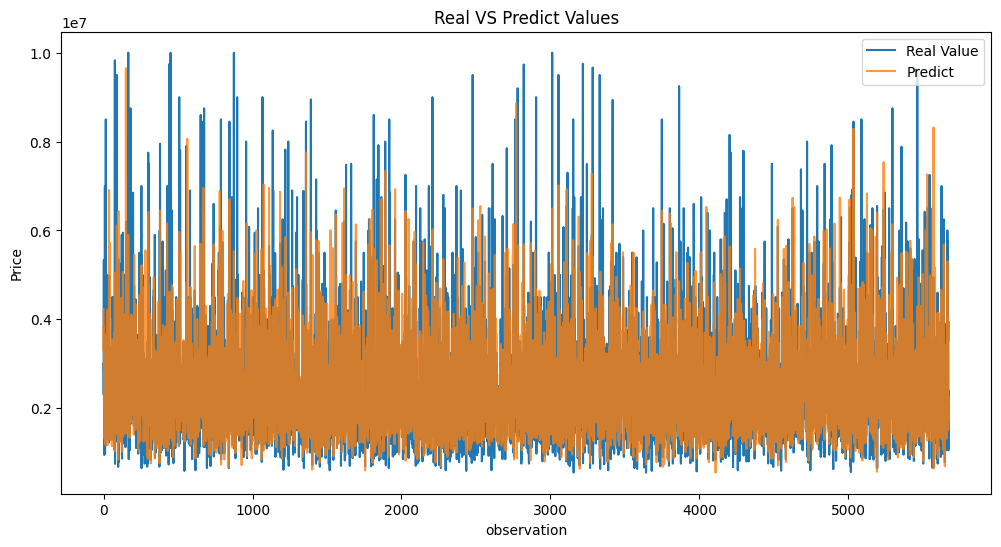

In [7]:
plt.figure(figsize=(12,6))


plt.plot(y_test.values, label="Real Value")
plt.plot(y_pred_best, label="Predict", alpha=0.8)

plt.title("Real VS Predict Values")
plt.xlabel("observation")
plt.ylabel("Price")

plt.legend()
plt.show()

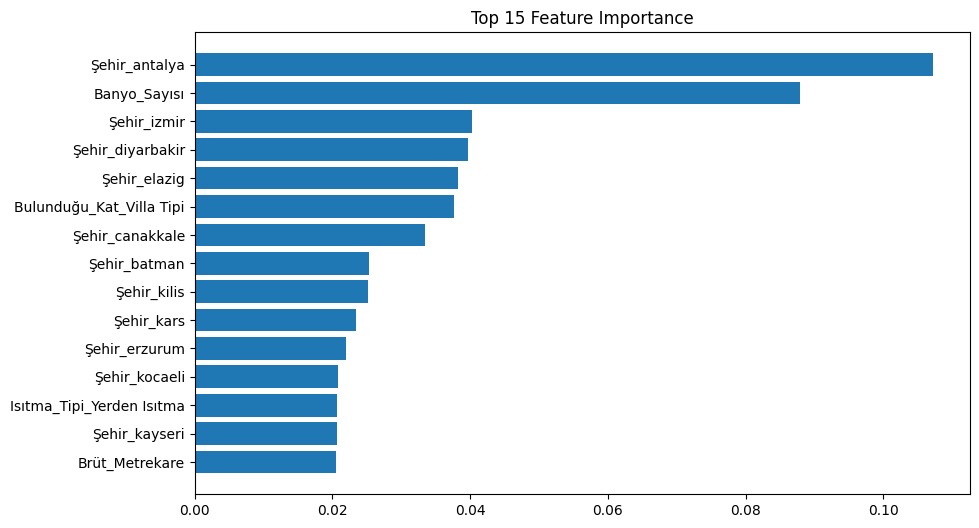

In [8]:
import pandas as pd

importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.title("Top 15 Feature Importance")
plt.gca().invert_yaxis()

plt.show()

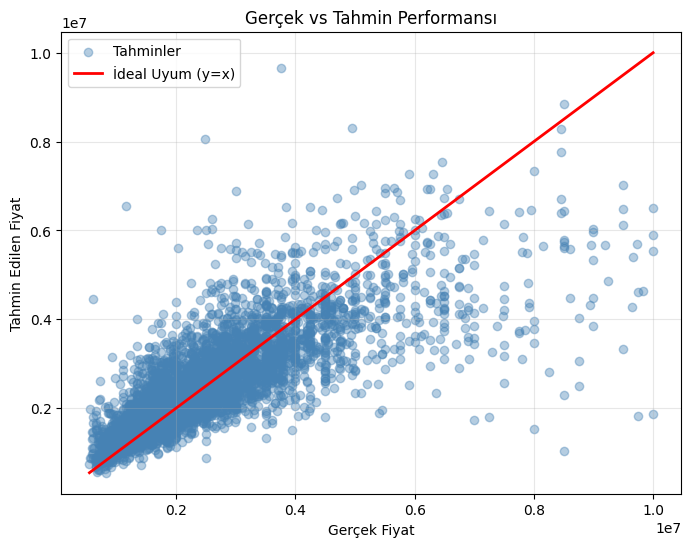

In [9]:
import matplotlib.pyplot as plt

# Örnek çizim alanı boyutu
plt.figure(figsize=(8, 6))

# alpha=0.4 ile noktaları saydamlaştırıp üst üste binmeleri (yoğunluğu) gösteriyoruz
plt.scatter(y_test, y_pred_best, alpha=0.4, color='steelblue', label='Tahminler')

# Kırmızı ideal tahmin çizgisi (y=x doğrusu)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linewidth=2, label='İdeal Uyum (y=x)')

# Etiketler ve ızgara
plt.xlabel("Gerçek Fiyat")
plt.ylabel("Tahmin Edilen Fiyat")
plt.title("Gerçek vs Tahmin Performansı")
plt.grid(True, alpha=0.3)
plt.legend()

# Grafiği kaydetmek istersen:
# plt.savefig("temiz_grafik.png", dpi=300)